In [1]:
from pathlib import Path
import sys
import numpy as np

PROJECT_ROOT = Path("..").resolve()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from IPython.display import Audio


In [2]:
from spectral_mixture_analysis.audio import load_mono_audio, match_length, mix_signals
from spectral_mixture_analysis.transforms import (
    magnitude_spectrogram,
    amplitude_to_db,
    compute_representation,
    representation_to_db
)
from spectral_mixture_analysis.metrics import l2_error, relative_l2_error
from spectral_mixture_analysis.plotting import plot_spectrogram, plot_difference_map

In [3]:
audio_path_1 = PROJECT_ROOT / "data" / "samples" / "flute" / "Track1_flute.wav"
audio_path_2 = PROJECT_ROOT / "data" / "samples" / "bass" / "Track10_Bass.wav"
x, sr = load_mono_audio(audio_path_1, sr=22050)
y, _ = load_mono_audio(audio_path_2, sr=22050)

x, y = match_length(x, y, mode="truncate")
mix = x + y

In [4]:
from spectral_mixture_analysis.dataset import build_sample_index

samples_root = PROJECT_ROOT / "data" / "samples"
index_df = build_sample_index(samples_root)

index_df.head(12)

,instrument,track_id,path,filename
0,bass,1,/home/satan/git/spectrogram-analysis/data/samp...,Track1_Bass.wav
1,flute,1,/home/satan/git/spectrogram-analysis/data/samp...,Track1_flute.wav
2,piano,1,/home/satan/git/spectrogram-analysis/data/samp...,Track1_Acoustic_Grand_Piano.wav
3,trumpet,1,/home/satan/git/spectrogram-analysis/data/samp...,Track1_trumpet.wav
4,bass,2,/home/satan/git/spectrogram-analysis/data/samp...,Track2_Bass.wav
5,flute,2,/home/satan/git/spectrogram-analysis/data/samp...,Track2_flute.wav
6,piano,2,/home/satan/git/spectrogram-analysis/data/samp...,Track2_Acoustic_Grand_Piano.wav
7,trumpet,2,/home/satan/git/spectrogram-analysis/data/samp...,Track2_trumpet.wav
8,bass,3,/home/satan/git/spectrogram-analysis/data/samp...,Track3_Bass.wav
9,flute,3,/home/satan/git/spectrogram-analysis/data/samp...,Track3_flute.wav


In [5]:
from spectral_mixture_analysis.dataset import get_track_instrument_pairs, get_same_pair_across_tracks

pairs_track_1 = get_track_instrument_pairs(index_df, track_id=1)
pairs_bass_flute = get_same_pair_across_tracks(index_df, "bass", "flute")

In [6]:

print("Audio x")
display(Audio(x, rate=sr))

print("Audio y")
display(Audio(y, rate=sr))

print("Mixture x+y")
mix_listen = mix / (np.max(np.abs(mix)) + 1e-9)
display(Audio(mix_listen, rate=sr))

Audio x


Audio y


Mixture x+y


In [7]:
N_FFT = 2048
HOP = 512

X = compute_representation(x, sr, transform_type="mel", n_fft=N_FFT, hop_length=HOP)
Y = compute_representation(y, sr, transform_type="mel", n_fft=N_FFT, hop_length=HOP)
M = compute_representation(mix, sr, transform_type="mel", n_fft=N_FFT, hop_length=HOP)

mag_x = magnitude_spectrogram(X)
mag_y = magnitude_spectrogram(Y)
mag_mix = magnitude_spectrogram(M)
mag_sum = mag_x + mag_y

mix_db = amplitude_to_db(mag_mix)
sum_db = amplitude_to_db(mag_sum)
diff = mag_mix - mag_sum



In [8]:
overlap_2 = np.sum(np.minimum(mag_x, mag_y)) / np.sum(mag_x + mag_y)
overlap_2_db = representation_to_db(np.array([overlap_2]), ref=1.0, scale="amplitude")[0]
print(f"Overlap (rep): {overlap_2:.4f} ({overlap_2_db:.2f} dB)")

Overlap (rep): 0.0005 (-66.68 dB)


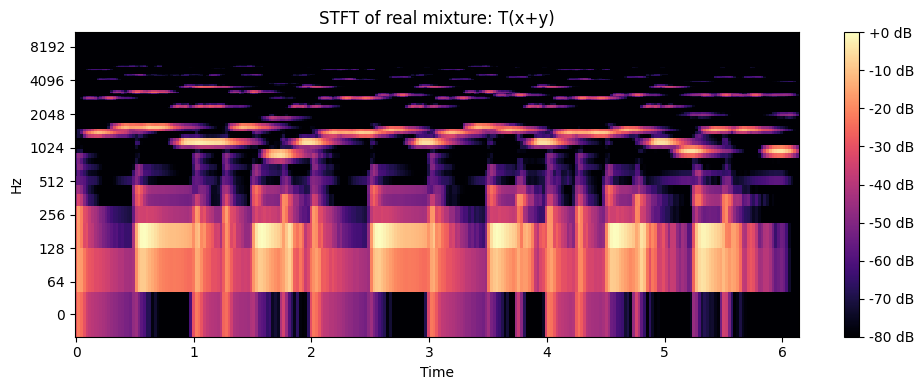

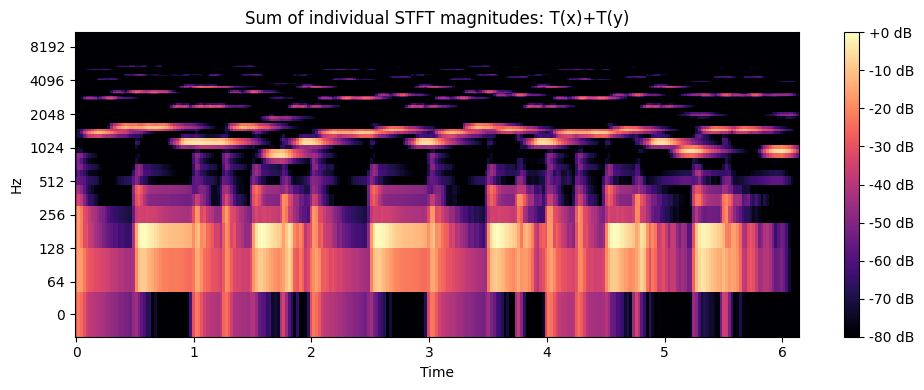

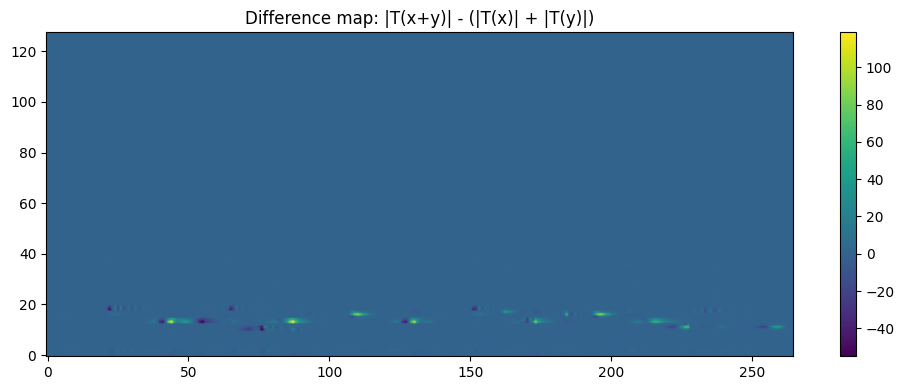

In [9]:
plot_spectrogram(mix_db, sr=sr, hop_length=HOP, title="STFT of real mixture: T(x+y)")
plot_spectrogram(sum_db, sr=sr, hop_length=HOP, title="Sum of individual STFT magnitudes: T(x)+T(y)")
plot_difference_map(diff, title="Difference map: |T(x+y)| - (|T(x)| + |T(y)|)")

In [11]:
from spectral_mixture_analysis.analysis import evaluate_mixture_linearity

metrics = evaluate_mixture_linearity(x, y, sr=sr, transform_type="mel", n_fft=N_FFT, hop_length=HOP)

print(metrics)

{'l2': 480.2690124511719, 'relative_l2': 0.00927350390702486, 'mae': 0.22951866686344147, 'overlap': 0.0004632251802831888}


In [14]:
from spectral_mixture_analysis.analysis import evaluate_dataset_pairs

pairs = [
    (PROJECT_ROOT / "data" / "raw" / "audio01_bass.wav",
     PROJECT_ROOT / "data" / "raw" / "audio02_vocal.wav"),

    (PROJECT_ROOT / "data" / "raw" / "audio03_bass.wav",
     PROJECT_ROOT / "data" / "raw" / "audio04_flute.wav"),

    (PROJECT_ROOT / "data" / "raw" / "audio05_guitar_aco.wav",
     PROJECT_ROOT / "data" / "raw" / "audio06_guitar_ele.wav"),

    (PROJECT_ROOT / "data" / "raw" / "audio07_keyboard_aco.wav",
     PROJECT_ROOT / "data" / "raw" / "audio08_keyboard_ele.wav"),

    (PROJECT_ROOT / "data" / "raw" / "audio09_keyboard_ele.wav",
     PROJECT_ROOT / "data" / "raw" / "audio10_organ_ele.wav"),
     
    (PROJECT_ROOT / "data" / "samples" / "flute" / "Track1_flute.wav",
     PROJECT_ROOT / "data" / "samples" / "bass" / "Track10_Bass.wav")
]

df = evaluate_dataset_pairs(pairs, transform_type="mel", n_fft=N_FFT, hop_length=HOP)

df

,file_x,file_y,transform_type,l2,relative_l2,mae,overlap
0,audio01_bass,audio02_vocal,mel,1499.686523,0.066072,0.667198,0.011845
1,audio03_bass,audio04_flute,mel,299.425507,0.014193,0.196864,0.000489
2,audio05_guitar_aco,audio06_guitar_ele,mel,516.347473,0.026394,0.222409,0.004629
3,audio07_keyboard_aco,audio08_keyboard_ele,mel,1272.781738,0.089181,0.442437,0.020451
4,audio09_keyboard_ele,audio10_organ_ele,mel,6951.863281,0.118732,4.458412,0.024890
5,Track1_flute,Track10_Bass,mel,480.269012,0.009274,0.229519,0.000463


In [15]:
from spectral_mixture_analysis.analysis import evaluate_dataset_pairs

pairs_bass_flute = get_same_pair_across_tracks(index_df, "bass", "flute")
df_bass_flute = evaluate_dataset_pairs(pairs_bass_flute, transform_type="mel", n_fft=N_FFT, hop_length=HOP)

df_bass_flute

,file_x,file_y,transform_type,l2,relative_l2,mae,overlap
0,Track1_Bass,Track1_flute,mel,352.240417,0.007407,0.150218,0.000816
1,Track2_Bass,Track2_flute,mel,95.107048,0.001850,0.046788,0.000038
2,Track3_Bass,Track3_flute,mel,10.367487,0.000282,0.009349,0.000015
3,Track4_Bass,Track4_flute,mel,48.967518,0.001273,0.029383,0.000068
4,Track5_Bass,Track5_flute,mel,65.349747,0.001170,0.029817,0.000062
5,Track6_Bass,Track6_flute,mel,66.204201,0.001364,0.049952,0.000107
6,Track7_Bass,Track7_flute,mel,156.752899,0.002258,0.076969,0.000044
7,Track8_Bass,Track8_flute,mel,268.398804,0.004647,0.076973,0.000137
8,Track9_Bass,Track9_flute,mel,680.559998,0.016868,0.206300,0.001378
9,Track10_Bass,Track10_flute,mel,503.057861,0.008024,0.201730,0.000188


In [16]:
pairs_track_1 = get_track_instrument_pairs(index_df, track_id=1)
df_track_1 = evaluate_dataset_pairs(pairs_track_1, transform_type="mel", n_fft=N_FFT, hop_length=HOP)

df_track_1

,file_x,file_y,transform_type,l2,relative_l2,mae,overlap
0,Track1_Bass,Track1_flute,mel,352.240417,0.007407,0.150218,0.000816
1,Track1_Bass,Track1_Acoustic_Grand_Piano,mel,2196.375977,0.053721,1.547338,0.010151
2,Track1_Bass,Track1_trumpet,mel,119.881927,0.003429,0.061149,0.001347
3,Track1_flute,Track1_Acoustic_Grand_Piano,mel,6450.539551,0.142101,3.093210,0.106626
4,Track1_flute,Track1_trumpet,mel,6548.473145,0.201898,4.317551,0.040635
5,Track1_Acoustic_Grand_Piano,Track1_trumpet,mel,1820.288452,0.075473,1.111682,0.033358


In [17]:
from spectral_mixture_analysis.analysis import evaluate_dataset_pairs

pairs_piano_trumpet = get_same_pair_across_tracks(index_df, "piano", "trumpet")
df_piano_trumpet = evaluate_dataset_pairs(pairs_piano_trumpet, transform_type="mel", n_fft=N_FFT, hop_length=HOP)

df_piano_trumpet

,file_x,file_y,transform_type,l2,relative_l2,mae,overlap
0,Track1_Acoustic_Grand_Piano,Track1_trumpet,mel,1820.288452,0.075473,1.111682,0.033358
1,Track2_Acoustic_Grand_Piano,Track2_trumpet,mel,826.149292,0.029205,0.335684,0.009074
2,Track3_Acoustic_Grand_Piano,Track3_trumpet,mel,280.556763,0.010454,0.122121,0.001293
3,Track4_Acoustic_Grand_Piano,Track4_trumpet,mel,197.887421,0.011240,0.060550,0.002745
4,Track5_Acoustic_Grand_Piano,Track5_trumpet,mel,322.461945,0.013707,0.129738,0.002028
5,Track6_Acoustic_Grand_Piano,Track6_trumpet,mel,166.800537,0.008797,0.120790,0.001903
6,Track7_Acoustic_Grand_Piano,Track7_trumpet,mel,436.602966,0.016013,0.263253,0.003095
7,Track8_Acoustic_Grand_Piano,Track8_trumpet,mel,745.886047,0.033916,0.490958,0.004912
8,Track9_Acoustic_Grand_Piano,Track9_trumpet,mel,353.171173,0.020055,0.126898,0.003131
9,Track10_Acoustic_Grand_Piano,Track10_trumpet,mel,627.944397,0.024773,0.387892,0.005989


In [18]:

print("Bass-Flute pairs:", df_bass_flute["relative_l2"].mean())
print("Piano-Trumpet pairs:", df_piano_trumpet["relative_l2"].mean())

Bass-Flute pairs: 0.0039751506493692955
Piano-Trumpet pairs: 0.025871836779905216


In [20]:
import pandas as pd
from spectral_mixture_analysis.audio import load_mono_audio, match_length
from spectral_mixture_analysis.analysis import evaluate_mixture_linearity


results = []

for path_x, path_y in pairs:
    x, sr = load_mono_audio(path_x)
    y, _ = load_mono_audio(path_y)

    x, y = match_length(x, y, mode="truncate")

    metrics = evaluate_mixture_linearity(
        x=x,
        y=y,
        sr=sr,
        transform_type="mel",   # ou "mel"
        # output="magnitude",      # só para STFT
        include_overlap=True,
        n_fft=2048,
        hop_length=512,
    )

    results.append({
        "file_x": path_x.name,
        "file_y": path_y.name,
        **metrics
    })

df = pd.DataFrame(results)
df

,file_x,file_y,l2,relative_l2,mae,overlap
0,audio01_bass.wav,audio02_vocal.wav,1499.686523,0.066072,0.667198,0.011845
1,audio03_bass.wav,audio04_flute.wav,299.425507,0.014193,0.196864,0.000489
2,audio05_guitar_aco.wav,audio06_guitar_ele.wav,516.347473,0.026394,0.222409,0.004629
3,audio07_keyboard_aco.wav,audio08_keyboard_ele.wav,1272.781738,0.089181,0.442437,0.020451
4,audio09_keyboard_ele.wav,audio10_organ_ele.wav,6951.863281,0.118732,4.458412,0.024890
5,Track1_flute.wav,Track10_Bass.wav,480.269012,0.009274,0.229519,0.000463


In [21]:
corr = df["overlap"].corr(df["relative_l2"])
print("Correlation (overlap vs relative_l2):", corr)

Correlation (overlap vs relative_l2): 0.9938086377602698


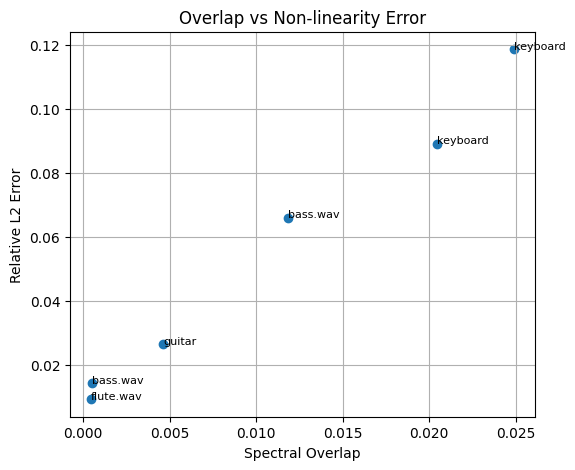

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.scatter(df["overlap"], df["relative_l2"])

for i, row in df.iterrows():
    plt.text(row["overlap"], row["relative_l2"], row["file_x"].split("_")[1], fontsize=8)

plt.xlabel("Spectral Overlap")
plt.ylabel("Relative L2 Error")
plt.title("Overlap vs Non-linearity Error")
plt.grid(True)
plt.show()

In [23]:
df.describe()

,l2,relative_l2,mae,overlap
count,6.000000,6.000000,6.000000,6.000000
mean,1836.728923,0.053974,1.036140,0.010461
std,2551.192896,0.044544,1.686281,0.010424
min,299.425507,0.009274,0.196864,0.000463
25%,489.288628,0.017243,0.224187,0.001524
50%,894.564606,0.046233,0.335978,0.008237
75%,1442.960327,0.083404,0.611008,0.018299
max,6951.863281,0.118732,4.458412,0.024890


In [24]:
print("Mean relative L2:", df["relative_l2"].mean())
print("Std relative L2:", df["relative_l2"].std())

Mean relative L2: 0.05397418839856982
Std relative L2: 0.04454381554370884
